# Aula 5 - Introdução às Bibliotecas Python e NumPy

## Objetivos da Aula

Nesta aula, você aprenderá:
- Como instalar bibliotecas de terceiros
- Os básicos do NumPy 
- Pandas I
    - Carregar dados de xcls e csv para Pandas
    - Fatiar tabelas e plotar gráficos simples


## Estrutura da Aula
1. PiP
2. NumPy
4. Pandas
    1. DataFrame
    2. Series
    3. carregar dados do excel, csv...
    4. métodos e atributos de resumo
    (head, tail, describe, shape, dtypes,
    info...)
    5. métodos de fatiamento
    (loc, iloc, iat, at, T...)
    6. métodos gráficos
    (hist, plot, scatter)


## Material Complementar (Opcional)
1. Pesquise sobre a biblioteca **Pandas** e **NumPy**.
2. Leia a documentação oficial.
3. Entenda algum método ou função específica.
4. Replique com um código de teste.

 [Documentação PiP](https://pip.pypa.io/en/stable/)

 [Documentação Numpy](https://numpy.org/doc/stable/)

 [Documentação Pandas](https://pandas.pydata.org/docs/user_guide/)

---

## **Preparando nosso ambiente virtual**

Como hoje iremos instalar código de terceiros em nosso jupyter é importante manter isso separado dentro de um ambiente virtual do python.

No caso de um projeto fora de um jupyternotebook fariamos "python3 -m venv .venv" para criar e "source .venv/bin/activate" para ativar.

Como nosso caso é outro as melhores maneiras são criando um venv pela interface do ViSual-Code ou escolhendo seu kernel preferido na interface do notebook ou não fazendo nada no caso de um colab no google drive, pois lá cada arquivo é um venv em si.
Após configurar seu ambiente virtual, vamos começar a aula. Use em uma célula do notebook:

In [1]:

pip install numpy pandas matplotlib openpyxl

Note: you may need to restart the kernel to use updated packages.


In [ ]:
#rode se estiver num repositorio do git antes de mexer nesse arquivo
open('.gitignore', 'w').write('.gitignore\n.venv/\n__pycache__/\n.ipynb_checkpoints/\ndata/\noutputs/\n')

Como vimos na aula anterior é primordial avisar ao python quais bibliotecas queremos que sejam carregadas no programa antes de usa-las. 
Nessa aula focaremos nas bibliotecas numpy e pandas, com a adição da openpyxl que faz o pandas ser capaz de ler arquivos do excel em tabelas.

In [ ]:
import numpy as np
import pandas as pd

: 

In [2]:
import numpy as np
import pandas as pd

# Introdição prática ao Numpy

Vamos ver alguns exemplos simples que mostram o comportamento das principais funções do `numpy` usadas em ciência de dados.

### **Criando arrays**

---

Numpy é uma poderosa ferramente para calculos cientificos, sendo ferozmente veloz no que é bom de fazer. 
Vamos primeiro ver alguns métodos que criam diversos vetores diferentes e depois aplicaremos Numpy em uma tarefa um tanto descolada da realidade.

In [6]:
# Criar arrays a partir de listas
a = np.array([1, 2, 3, 4, 0])
print('array a:', a)

# arange: intervalo com passo 1
b = np.arange(5, 10)
print('arange 0-9:', b)

# zeros: array preenchido com zeros
z = np.zeros((2, 3))
print('zeros 2x3:\n', z)

# linspace: 5 valores entre 0 e 1
l = np.linspace(0, 1, 5)
print('linspace 0-1:', l)

# random.rand: aleatórios em [0,1)
r = np.random.rand(5)
print('random:', r)


array a: [1 2 3 4 0]
arange 0-9: [5 6 7 8 9]
zeros 2x3:
 [[0. 0. 0.]
 [0. 0. 0.]]
linspace 0-1: [0.   0.25 0.5  0.75 1.  ]
random: [0.12238104 0.95003367 0.01233539 0.04531955 0.7589788 ]


### **Tamanho e formato de um array**

---

Diferentemente do python os arrays do Numpy são de tamanho fixo, portanto não se pode aumentar ou diminuir seus tamanhos de forma dinâmica, apenas mudar seus formatos e números. Uma dica muit útil é criar um array de zeros e preencher-lo dinamicamente caso o algoritmo não crie todos os números de uma vez só.

In [8]:

# reshape / flatten
# reshape muda o formato de seu array em qualquer matriz multidimensional
# flatten leva todas as matrizes a um array unidimensional
m = np.arange(6).reshape(2, 3)
print('matriz m:\n', m)
print('m flatten:', m.flatten())
print('m flatten:', m.reshape(1, 2, 3))

matriz m:
 [[0 1 2]
 [3 4 5]]
m flatten: [0 1 2 3 4 5]
m flatten: [[[0 1 2]
  [3 4 5]]]


### **Operações em Numpy**

---

Todas as operações básicas são mantidas, porém você estará aplicando as operações elemente a elemento vetorizada. Então se atente ao formato de cada elemento antes de operar um com o outro.

In [9]:
a+a+l

array([2.  , 4.25, 6.5 , 8.75, 1.  ])

In [10]:
l*a

array([0. , 0.5, 1.5, 3. , 0. ])

## **Exemplo de uso em Algebra Linear**

---

Agora já devemos saber o suficiente para atacar nosso problema... Tenho uma matriz qualquer, talvez quadrada, e gostaria de achar sua matriz de projeção. Ou seja, a matriz pela qual devo multiplicar meu conjunto de dados a fim de conseguir a matriz geratriz da solução com o erro mínimo.
Felizmente, não estamos aqui pela dedução matemática, isso já temos. Para um espaço vetorial $V$ a matriz de projeção $P$ dos vetores $v \in V$ em $X \subset V$ subespaço será:
$$P:V \rarr X \subseteq V \\ \space v \rarr X(X^{t}X)^{⁻1}X^{t}v$$

Vamos tomar $V$ como $R^{3}$ para facilitar a visualização, mesmo que não seja necessário fixar V.

In [16]:
x = np.zeros((3,2))
x

array([[0., 0.],
       [0., 0.],
       [0., 0.]])

In [19]:
#vamos popular a matriz x com valores, para que ela não seja singular
i=0
while i<6:
    # i%3, i//3 é uma maneira de mandar 1-9 -> (0,0)-(2,2) para passarmos em todos os pontos em x
    x[i%3, i//3] = float(input('coloque os números da matriz x'))
    i+=1
x

array([[1., 0.],
       [0., 1.],
       [0., 0.]])

Como Numpy é muito utilizado em contextos de Algebra Linear a bilbioteca tem todas as operações mais comuns já implementadas, em np.linalg.
Olhando a documentação do Numpy logo achamos o que precisamos fazer:
- `.T` em arrays devolve seu transposto 
- `np.linalg.pinv()` calcula a pseudo-inversa de uma matriz.
- `np.linalg.matmul()` faz multiplicação de matrizes como conhecemos em Algebra linear.

In [20]:
ln = np.linalg
x_t = x.T
#calcular a matriz quadrada por xtx
p = ln.matmul(x_t, x)
#achar sua pseudo-inversa
p = ln.pinv(p)
#multiplicar da esquerda para a direita
p = ln.matmul(p, x_t)
p = ln.matmul(x, p)
p



array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 0.]])

Será que o que nós calculamos é realmente nossa matriz de projeção?
podemos testar ela com algumas contas. 
Como ela projeta todos os vetores para um subespaço que normalmente não é igual a $V$ seu determinante deve ser 0.

In [21]:
ln.det(p) 

np.float64(0.0)

Uma caracteristica especial de $P$ é que $P$ deve ser simétrico e $1-P$ também. Vamos testar isso:

In [22]:
# vamos comparar cada elemento com o elemento oposto em P e 1-P
comparar = (p, 1-p)

In [23]:
for matriz in comparar:
    _bool = True
    j = 0
    while j<9:
        #comparar cada elemento com seu oposto
        _bool = _bool & (matriz[j%3, j//3] == matriz[j//3, j%3])
        
        if not _bool: # uma vez que _bool é falso já sabemos que a matriz não é simétrica
            break
        j+=1
    print(f'a matriz \n {matriz} {'não' if not _bool else ''} é simétrica')

a matriz 
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 0.]]  é simétrica
a matriz 
 [[0. 1. 1.]
 [1. 0. 1.]
 [1. 1. 1.]]  é simétrica


Bem, mas até onde podemos ver as matrizes são iguais... 

In [24]:
for matriz in comparar:
    print(matriz)
    print()

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 0.]]

[[0. 1. 1.]
 [1. 0. 1.]
 [1. 1. 1.]]



Elas realmente são iguais, o problema é a precisão finita do computador do float32. 
Como você resolveria esse problema? Fica como tarefa.


Uma dica: mude o tipo dos dados na matriz ou estabeleça uma precisão máxima para as comparações.

Existe uma maneira melhor de testar se $P$ é simétrico, quer tentar faze-la?

In [ ]:
# crie um código que não passe apenas pelas coordenadas necessárias para garantir que a matriz é simétrica
# ou procure uma maneira de fazer isso com o Numpy sem tem os mesmo problemas de antes

Agora que estamos um pouco mais certo que temos realmente $P$, vamos usar para projetar nosso vetor $v$ qualquer!

In [25]:
v = np.zeros((3,1))
v

array([[0.],
       [0.],
       [0.]])

In [26]:
#vamos popular o vetor v com valores
i=0
while i<3:
    v[i, 0] = float(input('coloque os números do vetor v'))
    i+=1
v

array([[  1.],
       [  2.],
       [170.]])

In [28]:
#veja que p é invariante em X
pp = np.linalg.matmul(p,p)

In [ ]:
p

In [27]:
np.linalg.matmul( p, v)

array([[1.],
       [2.],
       [0.]])

In [29]:
np.linalg.matmul( pp, v)

array([[1.],
       [2.],
       [0.]])

# Introdução ao Pandas

---

## Carregamento de dados no pandas
em geral
``` python
pd.read_ 
```
Te retornando um DataFrame

In [ ]:
# pd.read_excel
# pd.read_csv

## Entendendo DataFrame e Series


Um objeto do tipo ```Series``` no pandas é uma matriz unidimensional que contém dados de qualquer tipo, incluindo inteiros, flutuantes, strings, booleanos, objetos python etc. Um ```DataFrame``` é composto de muitas séries que funcionam como colunas. Ambos são objetos tabulares.

In [30]:
# Criando uma Series a partir de uma lista
temperaturas = pd.Series([30, 33, 40, 27, 18])
temperaturas

0    30
1    33
2    40
3    27
4    18
dtype: int64

In [38]:
# Alterando o índice de uma Series
temperaturas = pd.Series([30, 33, 40, 27, 18],
                         index = ["Seg", "Ter", "Qua", "Qui", "Sex"])
temperaturas

Seg    30
Ter    33
Qua    40
Qui    27
Sex    18
dtype: int64

In [35]:
temperaturas = temperaturas.reset_index(drop=True)
temperaturas

0    30
1    33
2    40
3    27
4    18
dtype: int64

In [40]:
# Acessando um valor da Series pelo índice
temperaturas['Qua']

np.int64(40)

In [41]:
# Criando um DataFrame a partir de um dicionário
pessoas = pd.DataFrame({'Nome': ['Maria', 'João', 'Ana'],
                      'Idade': [25, 30, 22],
                      'Cidade': ['São Paulo', 'Rio de Janeiro', 'Belo Horizonte']})
pessoas

,Nome,Idade,Cidade
0,Maria,25,São Paulo
1,João,30,Rio de Janeiro
2,Ana,22,Belo Horizonte


In [42]:
# Acessando colunas de um DataFrame com um par de colchete --> formato Series
pessoas['Nome']

0    Maria
1     João
2      Ana
Name: Nome, dtype: str

In [44]:
# Acessando colunas de um DataFrame com dois pares de colchetes --> formato DataFrame
pessoas[['Nome', 'Idade']]

,Nome,Idade
0,Maria,25
1,João,30
2,Ana,22


In [46]:
# Acessando intervalos de linhas com colchetes
# pessoas[:1]
pessoas[1:2]

,Nome,Idade,Cidade
1,João,30,Rio de Janeiro


# Exemplos práticos com Pandas
**pd.read_anything**

---

Vamos carregar um pequeno `DataFrame` das populações do Brasil, mostraremos as operações básicas de exploração e fatiamento.

In [ ]:
# Tentar carregar o arquivo Excel definido na pasta
df_pop = pd.read_excel(r'~/home/.../curso_de_python2026/pop.xlsx')
print('Arquivo carregado de:', "./pop.xlsx")


Arquivo carregado de: ./pop.xlsx


**Head e Tail**

---

Primeiramente é importante termos uma ideia geral de como devem ser as linhas de nossa tabela então usaremos os métodos HEAD e TAIL.

In [50]:
# Visualização inicial
print('--- head() ---')
print(df_pop.head())

--- head() ---
      CD_MUN                      NM_MUN POP_RESIDENTE  TX_CRESC  VAR_ABS
0  1100015.0  Alta Floresta D'Oeste - RO         21495     -1.05  -2897.0
1  1100023.0              Ariquemes - RO         96833      0.58   6480.0
2  1100031.0                 Cabixi - RO          5363     -1.35   -950.0
3  1100049.0                 Cacoal - RO         86895      0.84   8321.0
4  1100056.0             Cerejeiras - RO         15890     -0.58  -1139.0


In [51]:
# Visualização final
print('--- tail() ---')
print(df_pop.tail(6))

--- tail() ---
         CD_MUN               NM_MUN POP_RESIDENTE  TX_CRESC   VAR_ABS
5578  5221908.0          Varjao - GO          3716      0.13      57.0
5579  5222005.0      Vianopolis - GO         14956      1.47    2408.0
5580  5222054.0  Vicentinopolis - GO          8768      1.45    1395.0
5581  5222203.0        Vila Boa - GO          4215     -0.96    -520.0
5582  5222302.0   Vila Propicio - GO          5815      1.03     670.0
5583  5300108.0        Brasilia - DF       2817068      0.76  244909.0


**Shape e DTypes**

---

Nosso DataFrame tem duas propriedades importantes que é shape e dtypes. Elas contam do formato de sua tabela e os typos de dados que cada coluna abriga respectivamente. 

In [53]:
# Conferindo as dimensões do DataFrame a partir do '.shape'
df_pop.shape[0]


5584

In [54]:
# Conferindo os tipos de dados no DataFrame a partir do '.dtypes'
df_pop.dtypes


CD_MUN           float64
NM_MUN               str
POP_RESIDENTE        str
TX_CRESC         float64
VAR_ABS          float64
dtype: object

tipos_tabela = 
> {'CD_MUN'        :'int', \
> 'NM_MUN'        :'str', \
> 'POP_RESIDENTE' :'int', \
> 'TX_CRESC'      :'float', \
> 'VAR_ABS'       :'int'}



In [ ]:
# Conferindo os tipos de dados no DataFrame a partir do '.dtypes'
df_pop.dtypes


In [55]:
# Conferindo um resumo geral de nosso DF com info
df_pop.info()


<class 'pandas.DataFrame'>
RangeIndex: 5584 entries, 0 to 5583
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CD_MUN         5571 non-null   float64
 1   NM_MUN         5571 non-null   str    
 2   POP_RESIDENTE  5572 non-null   str    
 3   TX_CRESC       5571 non-null   float64
 4   VAR_ABS        5571 non-null   float64
dtypes: float64(3), str(2)
memory usage: 218.3 KB


Como queremos saber quantos valores nulos nossa tabela tem vamos usar .isnull que retornará uma nova tabela desta vez com valores booleanos (sim para null) e em seguida vamos somar cada coluna para conseguir uma medida que resume os números faltantes em cada coluna.

In [56]:
# Conferindo a quantidade de valores nulos no DataFrame a partir do '.isnull().sum()'
# df_pop.isnull()
df_pop.isnull().sum()


CD_MUN           13
NM_MUN           13
POP_RESIDENTE    12
TX_CRESC         13
VAR_ABS          13
dtype: int64

In [57]:
# Conferindo a quantidade de valores ausentes no DataFrame a partir do '.isna().sum()'
# df_pop.isna()
df_pop.isna().sum()


CD_MUN           13
NM_MUN           13
POP_RESIDENTE    12
TX_CRESC         13
VAR_ABS          13
dtype: int64

In [58]:
# Removendo valores nulos, usamos o inplace para afetar o DF diretamente e não uma cópia dele.
df_pop.dropna(inplace=True)


Ótimo os valores nulos não devem mais nos importunar!

In [59]:
# Preenchendo valores nulos
df_pop.isna().sum()


CD_MUN           0
NM_MUN           0
POP_RESIDENTE    0
TX_CRESC         0
VAR_ABS          0
dtype: int64

Vamos tentar novamente corrigir os tipos, agora que não temos valores nulos.

In [ ]:
# Acessando o índice de um DataFrame
df_pop.index


In [60]:
# Análise descritiva de um DataFrame
df_pop.describe()


,CD_MUN,TX_CRESC,VAR_ABS
count,5.571000e+03,5571.000000,5571.000000
mean,3.253007e+06,0.231343,2209.067133
std,9.857862e+05,1.074863,11896.937680
min,0.000000e+00,-4.890000,-257651.000000
25%,2.512089e+06,-0.400000,-349.500000
50%,3.146255e+06,0.130000,124.000000
75%,4.119177e+06,0.720000,1272.500000
max,5.300108e+06,9.230000,261533.000000


In [63]:
df_pop['POP_RESIDENTE'] = df_pop['POP_RESIDENTE'].astype(int)

Note algo estranho em nossa descrição estátistica da tabela, o mínimo das populções é **zero**! Cidades não deveriam ser vazias, teremos que tirar as cidades sem habitantes do DF. Aproveitemos e conferimos que cidade que tem uma população que leva o máximo para 1.145124e+07!

**Filtrando valores**

---

Então antes de continuar teremos que aprender como fazer filtros boleanos para nossas tabelas

In [64]:
#Filtremos nossa tabela pegando todas as cidades sem habitantes
Cidades_vazias = df_pop[df_pop['POP_RESIDENTE'] == 0]

# Tomamos apenas a lista de indices de nossa tabela temporária
indices = Cidades_vazias.index

# Usamos a função drop para remover as linhas referentes aos indices 
df_pop = df_pop.drop(indices)
df_pop.describe()

,CD_MUN,POP_RESIDENTE,TX_CRESC,VAR_ABS
count,5.570000e+03,5.570000e+03,5570.000000,5570.000000
mean,3.253591e+06,3.645647e+04,0.231384,2209.463734
std,9.849103e+05,2.065170e+05,1.074955,11897.968941
min,1.100015e+06,8.330000e+02,-4.890000,-257651.000000
25%,2.512126e+06,5.228000e+03,-0.400000,-349.750000
50%,3.146280e+06,1.106500e+04,0.130000,124.000000
75%,4.119190e+06,2.442725e+04,0.720000,1273.250000
max,5.300108e+06,1.145124e+07,9.230000,261533.000000


In [65]:
# Desfazendo a configuração de uma coluna como index
df_pop = df_pop.reset_index()
df_pop.head(3)


,index,CD_MUN,NM_MUN,POP_RESIDENTE,TX_CRESC,VAR_ABS
0,0,1100015.0,Alta Floresta D'Oeste - RO,21495,-1.05,-2897.0
1,1,1100023.0,Ariquemes - RO,96833,0.58,6480.0
2,2,1100031.0,Cabixi - RO,5363,-1.35,-950.0


In [73]:
df_pop.drop('index', axis=1, inplace=True)
df_pop.head(3)

,CD_MUN,NM_MUN,POP_RESIDENTE,TX_CRESC,VAR_ABS
0,1100031.0,Cabixi - RO,5363,-1.35,-950.0
1,1100049.0,Cacoal - RO,86895,0.84,8321.0
2,1100056.0,Cerejeiras - RO,15890,-0.58,-1139.0


In [68]:
# Podemos usar .astype() para converter tipos de dados
df_pop[['TX_CRESC',	'VAR_ABS']] = df_pop[['TX_CRESC',	'VAR_ABS']].astype(str)
df_pop.dtypes


CD_MUN           float64
NM_MUN               str
POP_RESIDENTE      int64
TX_CRESC             str
VAR_ABS              str
dtype: object

In [69]:
# Renomendo colunas ou linhas
#df_pop = df_pop.rename(columns={'CD_MUN':'Código_municipal',	
#                                   'NM_MUN':'Nome_municipio',	
#                                   'POP_RESIDENTE':'população',	
#                                   'TX_CRESC':'taxa_de_crescimento',	
#                                   'VAR_ABS':'Variação_absoluta'})
df_pop = df_pop.rename(index={0: 'Zero', 1: 'Um'})
df_pop.head(3)


,CD_MUN,NM_MUN,POP_RESIDENTE,TX_CRESC,VAR_ABS
Zero,1100015.0,Alta Floresta D'Oeste - RO,21495,-1.05,-2897.0
Um,1100023.0,Ariquemes - RO,96833,0.58,6480.0
2,1100031.0,Cabixi - RO,5363,-1.35,-950.0


In [70]:
# Removendo colunas ou linhas
# df_pop = df_pop.drop(columns=['Humidity'])
df_pop = df_pop.drop(index=['Zero', 'Um'])
df_pop.head(3)


,CD_MUN,NM_MUN,POP_RESIDENTE,TX_CRESC,VAR_ABS
2,1100031.0,Cabixi - RO,5363,-1.35,-950.0
3,1100049.0,Cacoal - RO,86895,0.84,8321.0
4,1100056.0,Cerejeiras - RO,15890,-0.58,-1139.0


In [74]:
df_pop = df_pop.reset_index(drop=True)
df_pop

,CD_MUN,NM_MUN,POP_RESIDENTE,TX_CRESC,VAR_ABS
0,1100031.0,Cabixi - RO,5363,-1.35,-950.0
1,1100049.0,Cacoal - RO,86895,0.84,8321.0
2,1100056.0,Cerejeiras - RO,15890,-0.58,-1139.0
3,1100064.0,Colorado do Oeste - RO,15663,-1.42,-2928.0
4,1100072.0,Corumbiara - RO,7519,-1.29,-1264.0
...,...,...,...,...,...
5563,5222005.0,Vianopolis - GO,14956,1.47,2408.0
5564,5222054.0,Vicentinopolis - GO,8768,1.45,1395.0
5565,5222203.0,Vila Boa - GO,4215,-0.96,-520.0
5566,5222302.0,Vila Propicio - GO,5815,1.03,670.0


In [75]:
# Utilizando máscaras para filtrar dados em DataFrames
df_pop[df_pop['TX_CRESC'] > 3]
df_pop[df_pop['POP_RESIDENTE'] >100_000]

TypeError: '>' not supported between instances of 'str' and 'int'

In [76]:
df_pop[df_pop['NM_MUN'] == 'Boa Vista - RR']

,CD_MUN,NM_MUN,POP_RESIDENTE,TX_CRESC,VAR_ABS
136,1400100.0,Boa Vista - RR,413486,3.17,129173.0


In [81]:
# Temos que usar o tipo correto para conseguir filtrar com facilidade o que buscamos nas tabelas
df_pop[['TX_CRESC']] = df_pop[['TX_CRESC']].astype(float)
df_pop[['VAR_ABS']] = df_pop[['VAR_ABS']].astype(float)

In [82]:
df_pop.dtypes

CD_MUN           float64
NM_MUN               str
POP_RESIDENTE      int64
TX_CRESC         float64
VAR_ABS          float64
dtype: object

In [ ]:
df_pop

In [86]:
# Utilizando máscaras para filtrar dados em DataFrames
df_pop[np.bitwise_and(df_pop['POP_RESIDENTE'] >100000,  df_pop['TX_CRESC'] > 3)]

,CD_MUN,NM_MUN,POP_RESIDENTE,TX_CRESC,VAR_ABS
136,1400100.0,Boa Vista - RR,413486,3.17,129173.0
238,1505536.0,Parauapebas - PA,266424,4.68,112516.0
631,2111201.0,Sao Jose de Ribamar - MA,244579,3.50,82642.0
2059,2919553.0,Luis Eduardo Magalhaes - BA,107909,5.00,47804.0
2766,3145208.0,Nova Serrana - MG,105552,3.04,31853.0
3213,3302700.0,Marica - RJ,197300,3.71,69903.0
3239,3304524.0,Rio das Ostras - RJ,156491,3.33,50811.0
4018,4107652.0,Fazenda Rio Grande - PR,148873,5.13,67198.0
4360,4203204.0,Camboriu - SC,103074,4.28,40713.0
4434,4208203.0,Itajai - SC,264054,3.09,80681.0


**Colunas e indices**

---

Vamos ver um pouco como lidar com as propriedades de coluna e indice de nossa tabela.

In [87]:
# Acessando as colunas de um DataFrame
df_pop.columns


Index(['CD_MUN', 'NM_MUN', 'POP_RESIDENTE', 'TX_CRESC', 'VAR_ABS'], dtype='str')

In [88]:
# Acessando o índice de um DataFrame
df_pop.index


RangeIndex(start=0, stop=5568, step=1)

In [89]:
# Configurando uma coluna do DataFrame como index
df_pop = df_pop.set_index('CD_MUN')
df_pop


,NM_MUN,POP_RESIDENTE,TX_CRESC,VAR_ABS
CD_MUN,,,,
1100031.0,Cabixi - RO,5363,-1.35,-950.0
1100049.0,Cacoal - RO,86895,0.84,8321.0
1100056.0,Cerejeiras - RO,15890,-0.58,-1139.0
1100064.0,Colorado do Oeste - RO,15663,-1.42,-2928.0
1100072.0,Corumbiara - RO,7519,-1.29,-1264.0
...,...,...,...,...
5222005.0,Vianopolis - GO,14956,1.47,2408.0
5222054.0,Vicentinopolis - GO,8768,1.45,1395.0
5222203.0,Vila Boa - GO,4215,-0.96,-520.0


In [90]:
# Desfazendo a configuração de uma coluna como index
df_pop = df_pop.reset_index()
df_pop


,CD_MUN,NM_MUN,POP_RESIDENTE,TX_CRESC,VAR_ABS
0,1100031.0,Cabixi - RO,5363,-1.35,-950.0
1,1100049.0,Cacoal - RO,86895,0.84,8321.0
2,1100056.0,Cerejeiras - RO,15890,-0.58,-1139.0
3,1100064.0,Colorado do Oeste - RO,15663,-1.42,-2928.0
4,1100072.0,Corumbiara - RO,7519,-1.29,-1264.0
...,...,...,...,...,...
5563,5222005.0,Vianopolis - GO,14956,1.47,2408.0
5564,5222054.0,Vicentinopolis - GO,8768,1.45,1395.0
5565,5222203.0,Vila Boa - GO,4215,-0.96,-520.0
5566,5222302.0,Vila Propicio - GO,5815,1.03,670.0


In [ ]:
# Utilizando máscaras para filtrar dados em DataFrames
df_pop[df_pop['TX_CRESC'] > 3]
df_pop[df_pop['POP_RESIDENTE'] >100000]

In [ ]:
# Renomendo colunas ou linhas
df_pop = df_pop.rename(columns={'CD_MUN':'Código_municipal',	
                                   'NM_MUN':'Nome_municipio',	
                                   'POP_RESIDENTE':'população',	
                                   'TX_CRESC':'taxa_de_crescimento',	
                                   'VAR_ABS':'Variação_absoluta'})
df_pop = df_pop.rename(index={0: 'Zero', 1: 'Um'})
df_pop.head(3)


,Código_municipal,Nome_municipio,população,taxa_de_crescimento,Variação_absoluta
Zero,1100031.0,Cabixi - RO,5363,-1.35,-950.0
Um,1100049.0,Cacoal - RO,86895,0.84,8321.0
2,1100056.0,Cerejeiras - RO,15890,-0.58,-1139.0


In [94]:
df_pop = df_pop.rename(columns={'taxa_de_crescimento':'Taxa_de_crescimento', 'população':'População'}, index={ 'Zero':0, 'Um':1})
df_pop 

,Código_municipal,Nome_municipio,População,Taxa_de_crescimento,Variação_absoluta
0,1100031.0,Cabixi - RO,5363,-1.35,-950.0
1,1100049.0,Cacoal - RO,86895,0.84,8321.0
2,1100056.0,Cerejeiras - RO,15890,-0.58,-1139.0
3,1100064.0,Colorado do Oeste - RO,15663,-1.42,-2928.0
4,1100072.0,Corumbiara - RO,7519,-1.29,-1264.0
...,...,...,...,...,...
5563,5222005.0,Vianopolis - GO,14956,1.47,2408.0
5564,5222054.0,Vicentinopolis - GO,8768,1.45,1395.0
5565,5222203.0,Vila Boa - GO,4215,-0.96,-520.0
5566,5222302.0,Vila Propicio - GO,5815,1.03,670.0


In [ ]:
# Removendo colunas ou linhas
# df_pop = df_pop.drop(columns=['Humidity'])
df_pop = df_pop.drop(index=['Zero', 'Um'])
df_pop.head(3)


In [95]:
df_pop[df_pop['Nome_municipio'] == 'Boa Vista - RR']

,Código_municipal,Nome_municipio,População,Taxa_de_crescimento,Variação_absoluta
136,1400100.0,Boa Vista - RR,413486,3.17,129173.0


In [96]:
df_pop['população_ano_anterior'] = df_pop['População'] + df_pop['Variação_absoluta']
df_pop

,Código_municipal,Nome_municipio,População,Taxa_de_crescimento,Variação_absoluta,população_ano_anterior
0,1100031.0,Cabixi - RO,5363,-1.35,-950.0,4413.0
1,1100049.0,Cacoal - RO,86895,0.84,8321.0,95216.0
2,1100056.0,Cerejeiras - RO,15890,-0.58,-1139.0,14751.0
3,1100064.0,Colorado do Oeste - RO,15663,-1.42,-2928.0,12735.0
4,1100072.0,Corumbiara - RO,7519,-1.29,-1264.0,6255.0
...,...,...,...,...,...,...
5563,5222005.0,Vianopolis - GO,14956,1.47,2408.0,17364.0
5564,5222054.0,Vicentinopolis - GO,8768,1.45,1395.0,10163.0
5565,5222203.0,Vila Boa - GO,4215,-0.96,-520.0,3695.0
5566,5222302.0,Vila Propicio - GO,5815,1.03,670.0,6485.0


<Axes: >

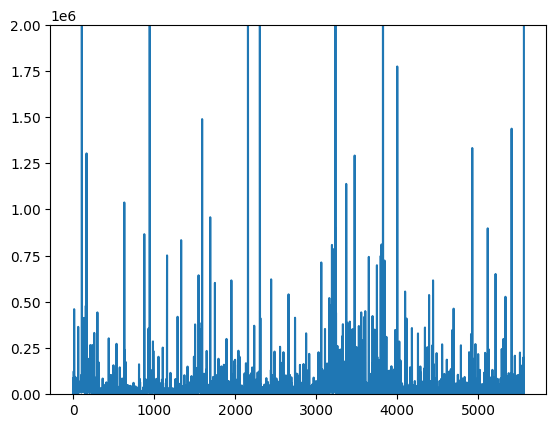

In [97]:
df_pop = df_pop.sort_index()
df_pop.reset_index(drop=True, inplace=True)

df_pop['População'].plot(ylim=(0, 2e6))


<Axes: >

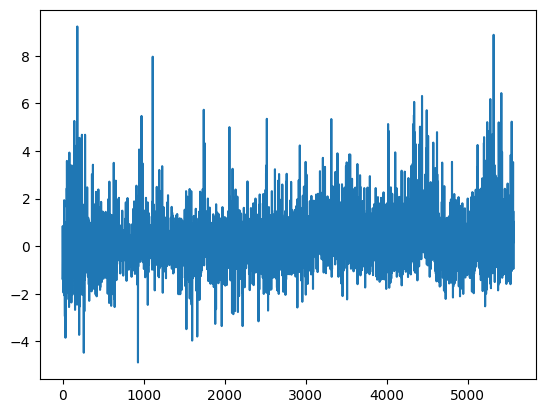

In [99]:
df_pop['Taxa_de_crescimento'].plot()

<Axes: title={'center': 'taxa de crescimento ordenada'}>

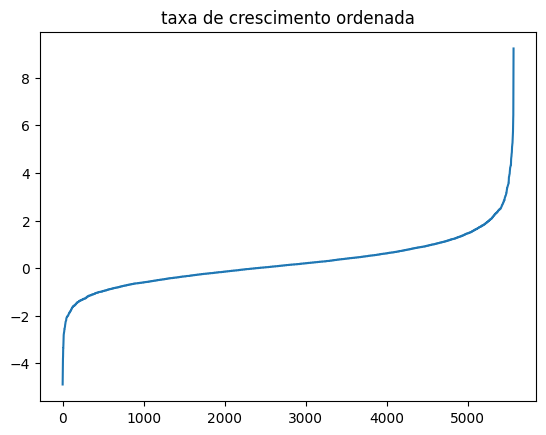

In [102]:
df_pop = df_pop.sort_values('Taxa_de_crescimento')
df_pop.reset_index(drop=True, inplace=True)

df_pop['Taxa_de_crescimento'].plot(title='taxa de crescimento ordenada')

<Axes: >

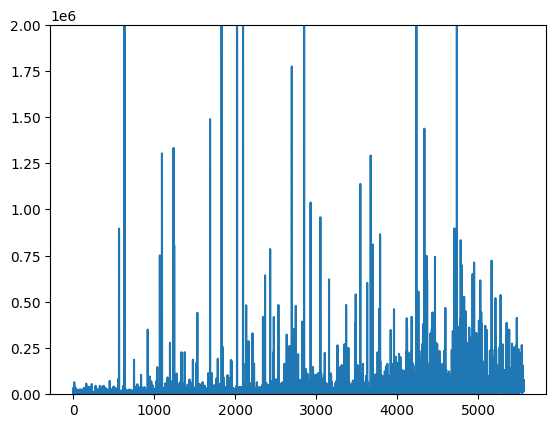

In [104]:
df_pop['População'].plot(ylim=(0, 2e6))

<Axes: xlabel='Taxa_de_crescimento', ylabel='População'>

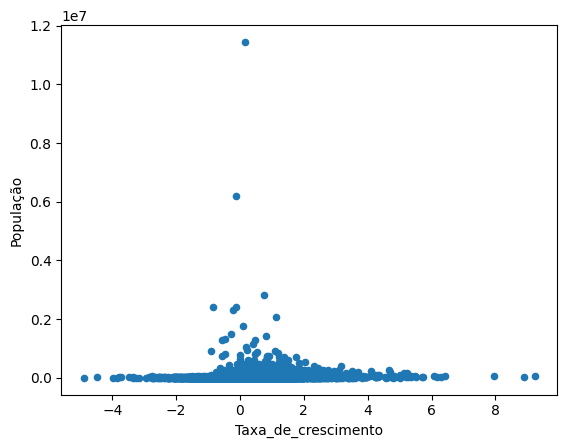

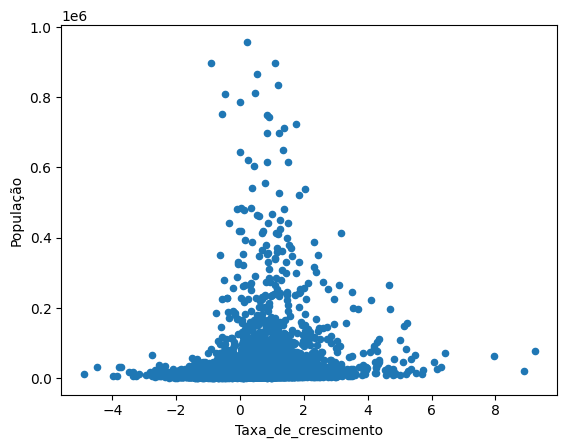

In [108]:
df_pop.plot.scatter('Taxa_de_crescimento', 'População')
df_pop[df_pop['População']<1e6].plot.scatter('Taxa_de_crescimento', 'População')